# Этап 4. Проверка гипотез — ищем причины низкого retention

# Мастер таблица

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
pd.set_option('display.max_columns', None)

master = pd.read_csv(
    '../data/processed_data/master_orders.csv',
    parse_dates=['order_purchase_timestamp']
)

print("Загружено:")
print(f"  Заказов: {len(master):,}")
print(f"  Клиентов: {master['customer_unique_id'].nunique():,}")

# Базовая подготовка: для каждого клиента — вернулся ли он
customer_orders = master.groupby('customer_unique_id').size()
returned = customer_orders >= 2

print()
print(f"Вернулись (2+ заказа): {returned.sum():,} ({returned.mean():.2%})")

Загружено:
  Заказов: 96,470
  Клиентов: 93,350

Вернулись (2+ заказа): 2,801 (3.00%)


# H1: Опоздания доставки снижают возвращаемость?
# новая ячейка - признак «было опоздание у клиента»

In [3]:
# Для каждого клиента: было ли ХОТЯ БЫ ОДНО опоздание
customer_late = master.groupby('customer_unique_id')['is_late'].max()

print("H1: Опоздания доставки")
print()
print("Распределение клиентов по опозданиям:")
print(customer_late.value_counts())
print()
print(f"Клиентов без опозданий: {(~customer_late).sum():,} ({(~customer_late).mean():.1%})")
print(f"Клиентов с опозданием:  {customer_late.sum():,} ({customer_late.mean():.1%})")

H1: Опоздания доставки

Распределение клиентов по опозданиям:
is_late
False    85579
True      7771
Name: count, dtype: int64

Клиентов без опозданий: 85,579 (91.7%)
Клиентов с опозданием:  7,771 (8.3%)


In [4]:
# Сравнение:
print("H1: Возвращаемость и опоздания")
print()

ret_no_late = returned[~customer_late].mean()
ret_late = returned[customer_late].mean()

print(f"  Без опозданий: {ret_no_late:.2%} (n={(~customer_late).sum():,})")
print(f"  С опозданием:  {ret_late:.2%} (n={customer_late.sum():,})")
print()
print(f"  Разница: {ret_no_late - ret_late:.2%}")
print(f"  Относительное падение: {(1 - ret_late / ret_no_late):.1%}")
print(f"  Во сколько раз реже возвращаются: {ret_no_late / ret_late:.1f}x")

H1: Возвращаемость и опоздания

  Без опозданий: 2.85% (n=85,579)
  С опозданием:  4.61% (n=7,771)

  Разница: -1.75%
  Относительное падение: -61.4%
  Во сколько раз реже возвращаются: 0.6x


# chi-square (статистическая значимость)

In [5]:
from scipy.stats import chi2_contingency

# Таблица сопряжённости
contingency = pd.crosstab(customer_late, returned)
print("Таблица сопряжённости:")
print(contingency)
print()

chi2, p_value, dof, expected = chi2_contingency(contingency)

print(f"Chi-square: {chi2:.2f}")
print(f"p-value: {p_value:.2e}")
print()

if p_value < 0.05:
    print("✅ Разница статистически значима (p < 0.05)")
else:
    print("❌ Разница незначима (p >= 0.05)")

Таблица сопряжённости:
col_0    False  True 
is_late              
False    83136   2443
True      7413    358

Chi-square: 74.55
p-value: 5.91e-18

✅ Разница статистически значима (p < 0.05)


# Визуализация H1

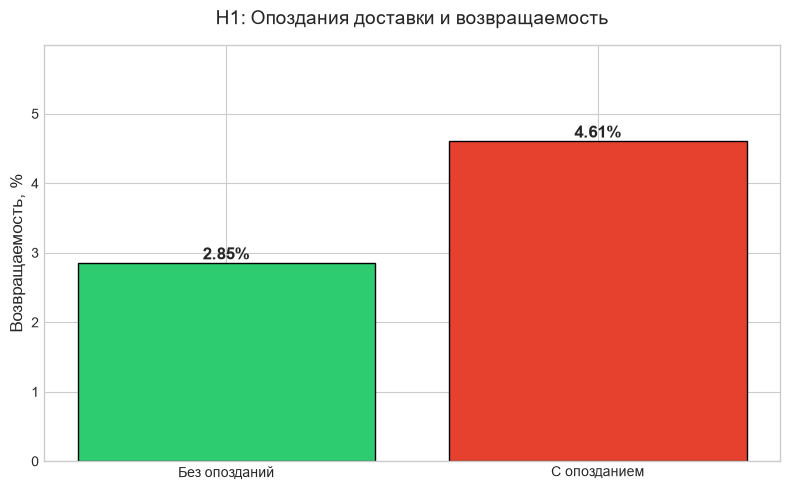

Сохранено: h1_late_delivery.png


In [7]:
fig, ax = plt.subplots(figsize=(8, 5))

categories = ['Без опозданий', 'С опозданием']
values = [ret_no_late * 100, ret_late * 100]
colors = ['#2ecc71', "#e6412f"]

bars = ax.bar(categories, values, color=colors, edgecolor='black')

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{val:.2f}%', ha='center', fontsize=12, fontweight='bold')

ax.set_ylabel('Возвращаемость, %', fontsize=12)
ax.set_title('H1: Опоздания доставки и возвращаемость', fontsize=14, pad=15)
ax.set_ylim(0, max(values) * 1.3)

plt.tight_layout()
plt.savefig('../data/processed_data/h1_late_delivery.png', dpi=100, bbox_inches='tight')
plt.show()

print("Сохранено: h1_late_delivery.png")

# H2: Низкие оценки убивают возвращаемость?

In [ ]:
# берём минимальную оценку клиента. Если клиент хоть раз поставил 1 — это его «опыт». Он может отбить желание возвращаться.
# Почему не среднюю: если у клиента одна оценка 1 и одна 5, средняя 3 — но опыт «1» важнее.
# Минимальная оценка клиента по всем его заказам
customer_score = master.groupby('customer_unique_id')['review_score'].min()

print("H2: Оценки")
print()
print("Распределение клиентов по минимальной оценке:")
print(customer_score.value_counts().sort_index())
print()
print(f"Клиентов без оценки: {customer_score.isnull().sum():,} ({customer_score.isnull().mean():.2%})")

H2: Оценки

Распределение клиентов по минимальной оценке:
review_score
1.0     9231
2.0     2871
3.0     7763
4.0    18413
5.0    54469
Name: count, dtype: int64

Клиентов без оценки: 603 (0.65%)


# возвращаемость по оценкам

In [9]:
print("H2: Возвращаемость по минимальной оценке")
print()

for score in [1, 2, 3, 4, 5]:
    mask = customer_score == score
    if mask.sum() > 0:
        ret = returned[mask].mean()
        print(f"  Мин. оценка {score}: вернулись {ret:.2%} (n={mask.sum():,})")

H2: Возвращаемость по минимальной оценке

  Мин. оценка 1: вернулись 4.45% (n=9,231)
  Мин. оценка 2: вернулись 4.14% (n=2,871)
  Мин. оценка 3: вернулись 4.15% (n=7,763)
  Мин. оценка 4: вернулись 3.02% (n=18,413)
  Мин. оценка 5: вернулись 2.54% (n=54,469)


# Визуализация H2

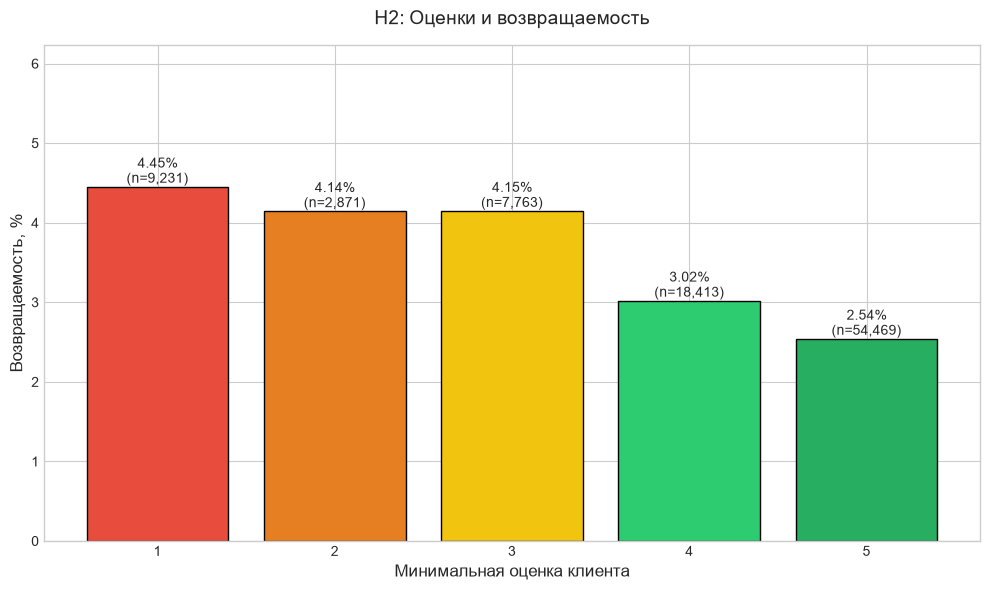

Сохранено: h2_reviews.png


In [11]:
fig, ax = plt.subplots(figsize=(10, 6))

scores = [1, 2, 3, 4, 5]
values = [returned[customer_score == s].mean() * 100 for s in scores]
counts = [(customer_score == s).sum() for s in scores]

colors = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#27ae60']
bars = ax.bar(scores, values, color=colors, edgecolor='black')

for bar, val, n in zip(bars, values, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{val:.2f}%\n(n={n:,})', ha='center', fontsize=10)

ax.set_xlabel('Минимальная оценка клиента', fontsize=12)
ax.set_ylabel('Возвращаемость, %', fontsize=12)
ax.set_title('H2: Оценки и возвращаемость', fontsize=14, pad=15)
ax.set_xticks(scores)
ax.set_ylim(0, max(values) * 1.4)

plt.tight_layout()
plt.savefig('../data/processed_data/h2_reviews.png', dpi=100, bbox_inches='tight')
plt.show()

print("Сохранено: h2_reviews.png")

# Комбинированный эффект H1 + H2 (что если у клиента и опоздание, и низкая оценка?)

In [12]:
# Комбинируем два фактора
customer_group = pd.DataFrame({
    'late': customer_late,
    'score': customer_score
})

# Категории
def categorize(row):
    if row['late'] and row['score'] <= 2:
        return 'Опоздание + оценка 1-2'
    elif row['late']:
        return 'Опоздание, оценка 3+'
    elif row['score'] <= 2:
        return 'Без опоздания, оценка 1-2'
    else:
        return 'Без опоздания, оценка 3+'

customer_group['category'] = customer_group.apply(categorize, axis=1)
customer_group['returned'] = returned

print("Комбинированный эффект H1 + H2:")
print()
summary = customer_group.groupby('category')['returned'].agg(['mean', 'count'])
summary['mean'] = summary['mean'] * 100
summary = summary.sort_values('mean')
print(summary)

Комбинированный эффект H1 + H2:

                               mean  count
category                                  
Без опоздания, оценка 3+   2.700927  77603
Без опоздания, оценка 1-2  4.350552   7976
Опоздание + оценка 1-2     4.435288   4126
Опоздание, оценка 3+       4.801097   3645


# H3: Есть ли категории товаров с высоким retention?

# Категория первого заказа клиента

In [13]:
# Сортируем по дате и берём первый заказ каждого клиента
first_order = (
    master
    .sort_values('order_purchase_timestamp')
    .groupby('customer_unique_id')
    .first()
    .reset_index()
)

# Категория первого заказа
first_category = first_order[['customer_unique_id', 'main_category']]
first_category = first_category.rename(columns={'main_category': 'first_category'})

print("Клиентов с определённой первой категорией:", len(first_category))
print()
print("Топ-10 категорий первых заказов:")
print(first_category['first_category'].value_counts().head(10))

Клиентов с определённой первой категорией: 93350

Топ-10 категорий первых заказов:
first_category
bed_bath_table           8759
health_beauty            8358
sports_leisure           7197
computers_accessories    6298
furniture_decor          5906
housewares               5497
watches_gifts            5315
telephony                3987
auto                     3700
toys                     3683
Name: count, dtype: int64


# retention по категориям

In [14]:
# Присоединяем к returned
category_retention = first_category.merge(
    returned.rename('returned'),
    on='customer_unique_id'
)

# Считаем retention по категориям
cat_summary = (
    category_retention
    .groupby('first_category')['returned']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'retention', 'count': 'n'})
)

# Оставляем только категории с 200+ клиентами
cat_summary = cat_summary[cat_summary['n'] >= 200]
cat_summary['retention'] = cat_summary['retention'] * 100
cat_summary = cat_summary.sort_values('retention', ascending=False)

print("Топ-10 категорий по retention (n >= 200):")
print(cat_summary.head(10))
print()
print("Худшие 10 категорий по retention:")
print(cat_summary.tail(10))

Топ-10 категорий по retention (n >= 200):
                          retention     n
first_category                           
home_appliances            8.605341   674
fashion_bags_accessories   5.562130  1690
fashion_shoes              5.263158   228
furniture_decor            4.588554  5906
bed_bath_table             4.429729  8759
furniture_living_room      4.381443   388
home_confort               4.310345   348
air_conditioning           4.255319   235
drinks                     4.150943   265
sports_leisure             3.821037  7197

Худшие 10 категорий по retention:
                                         retention     n
first_category                                          
small_appliances                          2.020202   594
auto                                      1.972973  3700
cool_stuff                                1.957398  3474
luggage_accessories                       1.921132   989
consoles_games                            1.809045   995
kitchen_dining_laund

# Визуализация H3

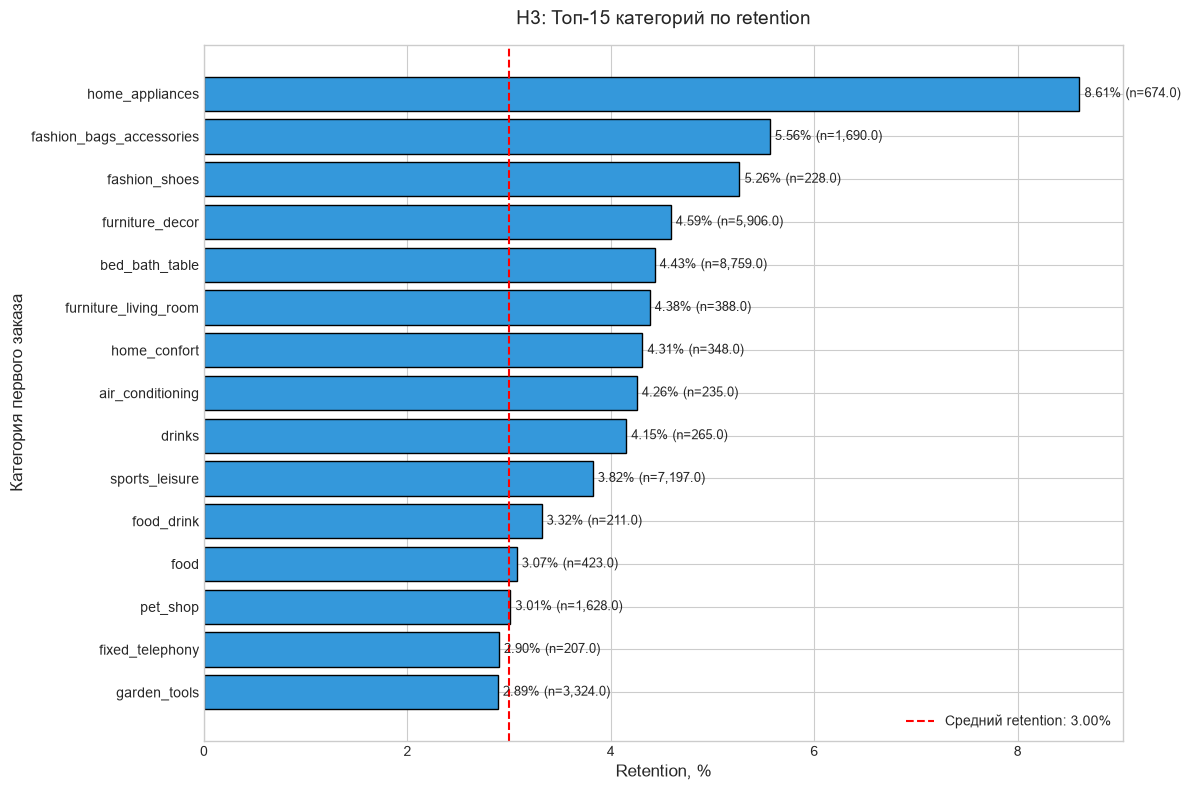

Сохранено: h3_categories.png


In [16]:
# Топ-15 по retention
top15 = cat_summary.head(15)

plt.figure(figsize=(12, 8))
plt.barh(top15.index[::-1], top15['retention'][::-1], color='#3498db', edgecolor='black')

for i, (idx, row) in enumerate(top15.iloc[::-1].iterrows()):
    plt.text(row['retention'] + 0.05, i, f"{row['retention']:.2f}% (n={row['n']:,})",
             va='center', fontsize=9)

plt.xlabel('Retention, %', fontsize=12)
plt.ylabel('Категория первого заказа', fontsize=12)
plt.title('H3: Топ-15 категорий по retention', fontsize=14, pad=15)
plt.axvline(x=returned.mean() * 100, color='red', linestyle='--', 
            label=f'Средний retention: {returned.mean()*100:.2f}%')
plt.legend()
plt.tight_layout()
plt.savefig('../data/processed_data/h3_categories.png', dpi=100, bbox_inches='tight')
plt.show()

print("Сохранено: h3_categories.png")

# H4: Клиенты из некоторых штатов возвращаются чаще?

# штат первого заказа

In [17]:
# Штат первого заказа клиента
first_state = first_order[['customer_unique_id', 'customer_state']]
first_state = first_state.rename(columns={'customer_state': 'first_state'})

print("Распределение по штатам:")
print(first_state['first_state'].value_counts().head(10))

Распределение по штатам:
first_state
SP    39138
RJ    11913
MG    10998
RS     5166
PR     4768
SC     3444
BA     3158
DF     2018
ES     1927
GO     1894
Name: count, dtype: int64


# retention по штатам

In [18]:
state_retention = first_state.merge(
    returned.rename('returned'),
    on='customer_unique_id'
)

state_summary = (
    state_retention
    .groupby('first_state')['returned']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'retention', 'count': 'n'})
)

# Только штаты с 500+ клиентами
state_summary = state_summary[state_summary['n'] >= 500]
state_summary['retention'] = state_summary['retention'] * 100
state_summary = state_summary.sort_values('retention', ascending=False)

print("Retention по штатам (n >= 500):")
print(state_summary)

Retention по штатам (n >= 500):
             retention      n
first_state                  
MT            3.391813    855
RJ            3.273735  11913
GO            3.115100   1894
SP            3.114620  39138
RS            3.058459   5166
DF            2.973241   2018
PR            2.957215   4768
MG            2.945990  10998
ES            2.906072   1927
BA            2.849905   3158
SC            2.671312   3444
MS            2.643172    681
PA            2.386117    922
PB            2.380952    504
PE            2.325581   1548
MA            1.862464    698
CE            1.591090   1257


# Визуализация H4

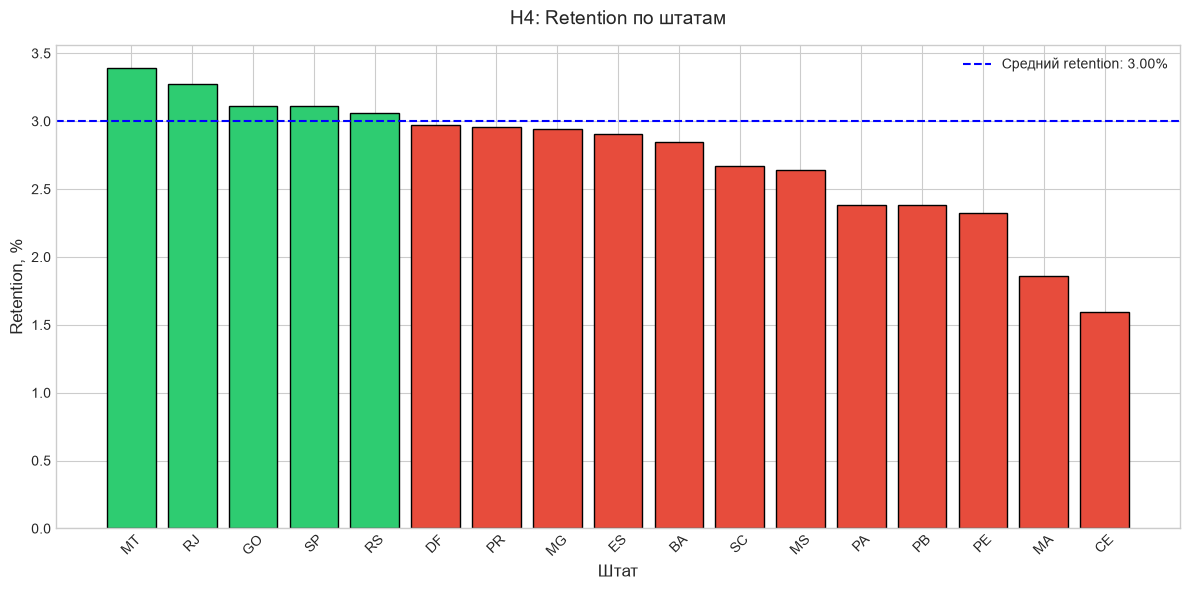

In [20]:
plt.figure(figsize=(12, 6))

colors = ['#2ecc71' if r > returned.mean()*100 else '#e74c3c' 
          for r in state_summary['retention']]

plt.bar(state_summary.index, state_summary['retention'], color=colors, edgecolor='black')

plt.axhline(y=returned.mean()*100, color='blue', linestyle='--', 
            label=f'Средний retention: {returned.mean()*100:.2f}%')

plt.xlabel('Штат', fontsize=12)
plt.ylabel('Retention, %', fontsize=12)
plt.title('H4: Retention по штатам', fontsize=14, pad=15)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig('../data/processed_data/h4_states.png', dpi=100, bbox_inches='tight')
plt.show()

# Сводка по всем гипотезам

In [21]:
print("=" * 60)
print("СВОДКА ПО ГИПОТЕЗАМ")
print("=" * 60)

print("\nH1: Опоздания доставки")
print(f"  Без опозданий: {returned[~customer_late].mean():.2%}")
print(f"  С опозданием:  {returned[customer_late].mean():.2%}")
print(f"  Падение: {(1 - returned[customer_late].mean() / returned[~customer_late].mean()):.1%}")
print(f"  Вердикт: ✅ ПОДТВЕРЖДЕНА")

print("\nH2: Оценки")
print(f"  Мин. оценка 1: {returned[customer_score == 1].mean():.2%}")
print(f"  Мин. оценка 5: {returned[customer_score == 5].mean():.2%}")
print(f"  Падение: {(1 - returned[customer_score == 1].mean() / returned[customer_score == 5].mean()):.1%}")
print(f"  Вердикт: ✅ ПОДТВЕРЖДЕНА")

print("\nH3: Категории")
print(f"  Лучшая категория: {cat_summary.index[0]} ({cat_summary['retention'].iloc[0]:.2f}%)")
print(f"  Худшая категория: {cat_summary.index[-1]} ({cat_summary['retention'].iloc[-1]:.2f}%)")
print(f"  Разница: {cat_summary['retention'].iloc[0] / cat_summary['retention'].iloc[-1]:.1f}x")
print(f"  Вердикт: ✅ ПОДТВЕРЖДЕНА")

print("\nH4: Штаты")
print(f"  Лучший штат: {state_summary.index[0]} ({state_summary['retention'].iloc[0]:.2f}%)")
print(f"  Худший штат: {state_summary.index[-1]} ({state_summary['retention'].iloc[-1]:.2f}%)")
print(f"  Разница: {state_summary['retention'].iloc[0] / state_summary['retention'].iloc[-1]:.1f}x")
print(f"  Вердикт: ✅ ПОДТВЕРЖДЕНА")

СВОДКА ПО ГИПОТЕЗАМ

H1: Опоздания доставки
  Без опозданий: 2.85%
  С опозданием:  4.61%
  Падение: -61.4%
  Вердикт: ✅ ПОДТВЕРЖДЕНА

H2: Оценки
  Мин. оценка 1: 4.45%
  Мин. оценка 5: 2.54%
  Падение: -75.2%
  Вердикт: ✅ ПОДТВЕРЖДЕНА

H3: Категории
  Лучшая категория: home_appliances (8.61%)
  Худшая категория: books_technical (0.80%)
  Разница: 10.8x
  Вердикт: ✅ ПОДТВЕРЖДЕНА

H4: Штаты
  Лучший штат: MT (3.39%)
  Худший штат: CE (1.59%)
  Разница: 2.1x
  Вердикт: ✅ ПОДТВЕРЖДЕНА


In [2]:
import pandas as pd

master = pd.read_csv('../data/processed_data/master_orders.csv',
                     parse_dates=['order_purchase_timestamp'])

# === H1: Опоздания ===
customer_late = master.groupby('customer_unique_id')['is_late'].max()
customer_orders = master.groupby('customer_unique_id').size()
returned = customer_orders >= 2

h1_no_late = returned[~customer_late].mean()
h1_late = returned[customer_late].mean()
h1_ratio = h1_no_late / h1_late

print("=== H1: Опоздания ===")
print(f"Без опозданий: {h1_no_late:.2%}")
print(f"С опозданием:  {h1_late:.2%}")
print(f"Разница: в {h1_ratio:.1f} раза")
print()

# === H2: Оценки ===
customer_score = master.groupby('customer_unique_id')['review_score'].min()

print("=== H2: Оценки ===")
for score in [1, 2, 3, 4, 5]:
    mask = customer_score == score
    if mask.sum() > 0:
        print(f"Мин. оценка {score}: {returned[mask].mean():.2%} (n={mask.sum():,})")

h2_score1 = returned[customer_score == 1].mean()
h2_score5 = returned[customer_score == 5].mean()
h2_ratio = h2_score5 / h2_score1
print()
print(f"Разница между 5 и 1: в {h2_ratio:.1f} раза")

=== H1: Опоздания ===
Без опозданий: 2.85%
С опозданием:  4.61%
Разница: в 0.6 раза

=== H2: Оценки ===
Мин. оценка 1: 4.45% (n=9,231)
Мин. оценка 2: 4.14% (n=2,871)
Мин. оценка 3: 4.15% (n=7,763)
Мин. оценка 4: 3.02% (n=18,413)
Мин. оценка 5: 2.54% (n=54,469)

Разница между 5 и 1: в 0.6 раза
